# Práctica 2: Aprendizaje No Supervisado
## Determinación de Tipos de Estrellas

**Asignatura:** Aprendizaje Automático — Universidad Carlos III de Madrid  
**Curso:** 2024–2025

| Nombre | NIA |
|--------|-----|
| Jorge López Alonso | 100495876 |
| Álvaro Carrasco Fuentes | 100495918 |

---

## Objetivo

Aplicar técnicas de aprendizaje no supervisado sobre un dataset de 240 estrellas con el fin de identificar agrupaciones naturales. Se utilizarán tres algoritmos de clustering (K-Means, Clustering Jerárquico y DBSCAN) precedidos de una reducción de dimensionalidad mediante PCA. Los resultados se compararán con las clases astronómicas reales.

**Semilla aleatoria base:** `100495876` (NIA de Jorge López Alonso)

## 1. Importaciones y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Semilla aleatoria base (NIA del grupo)
SEED = 100495876
np.random.seed(SEED)

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías cargadas correctamente.')
print(f'Semilla aleatoria: {SEED}')

Librerías cargadas correctamente.
Semilla aleatoria: 100495876


## 2. Carga y Exploración del Dataset (EDA)

In [2]:
df = pd.read_csv('../data/stars_data.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head(10)

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M
5,2840,0.000650,0.1100,16.98,Red,M
6,2637,0.000730,0.1270,17.22,Red,M
7,2600,0.000400,0.0960,17.40,Red,M
8,2650,0.000690,0.1100,17.45,Red,M
9,2700,0.000180,0.1300,16.05,Red,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


In [4]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


### 2.1 Variables Categóricas

In [5]:
print('Valores únicos en Color:')
print(df['Color'].value_counts().to_string(), '\n')
print('Valores únicos en Spectral_Class:')
print(df['Spectral_Class'].value_counts().to_string())

Valores únicos en Color:
Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1 

Valores únicos en Spectral_Class:
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1


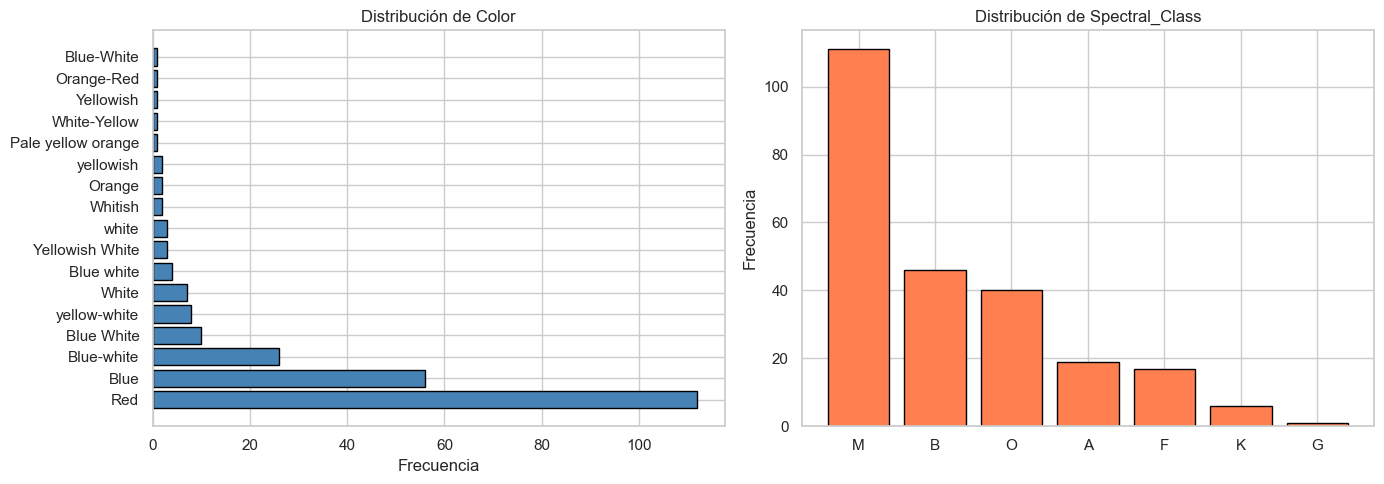

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_counts = df['Color'].value_counts()
axes[0].barh(color_counts.index, color_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Color')
axes[0].set_xlabel('Frecuencia')

spectral_counts = df['Spectral_Class'].value_counts()
axes[1].bar(spectral_counts.index, spectral_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Distribución de Spectral_Class')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 2.2 Distribuciones de Variables Numéricas

> **Nota**: Las variables `L` y `R` presentan rangos de varios órdenes de magnitud (ej. L va de 1.38×10⁻⁴ a 3.4×10⁵). Se visualizan tanto en escala lineal como logarítmica.

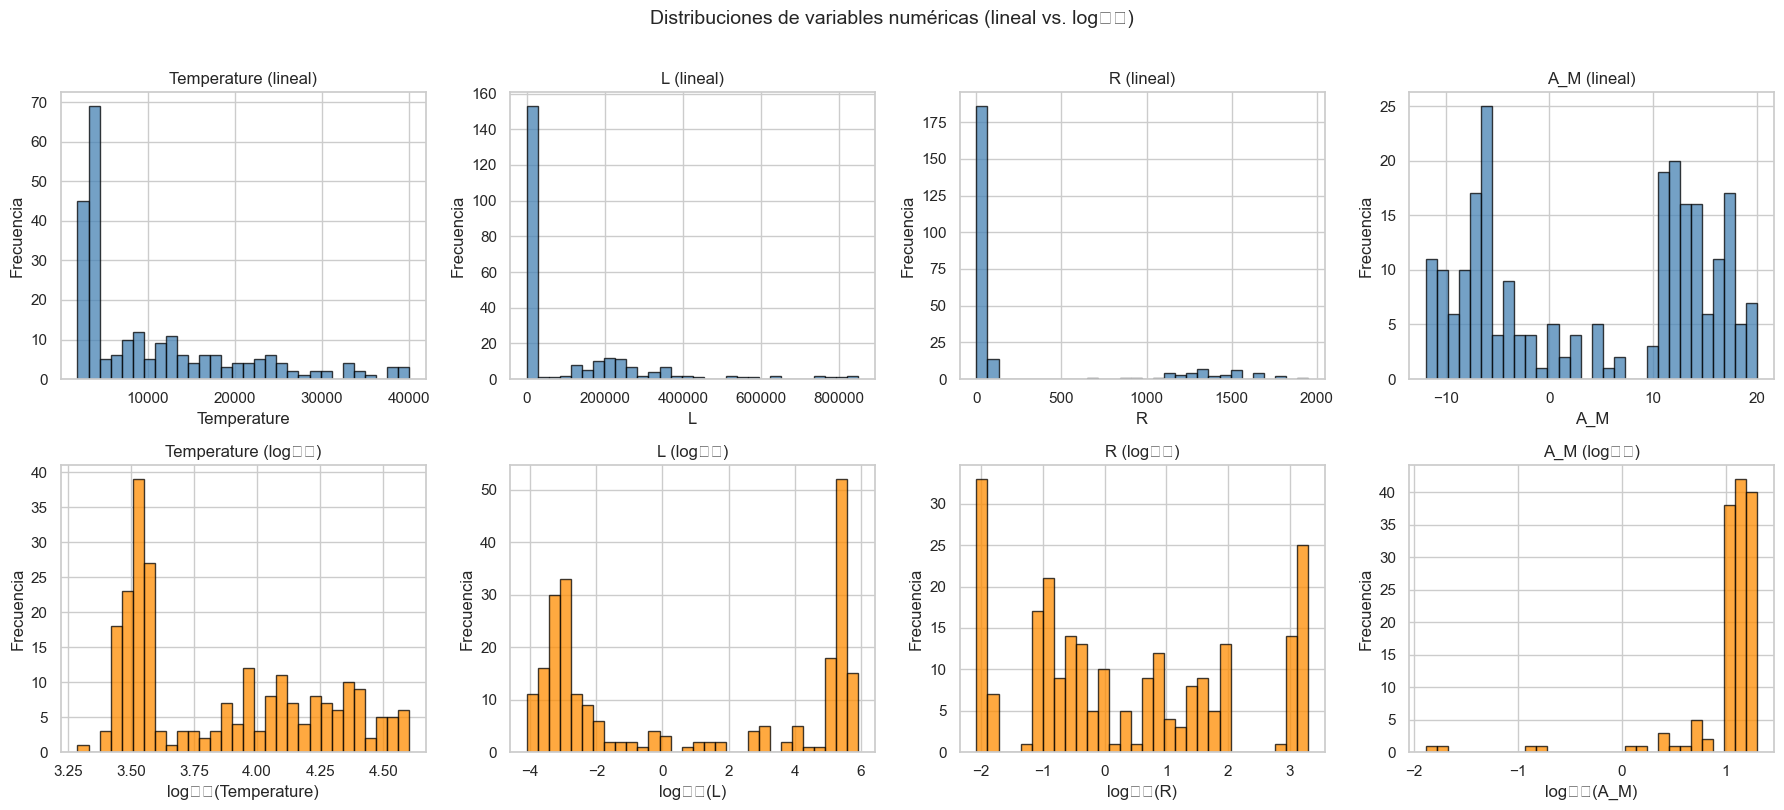

In [7]:
num_cols = ['Temperature', 'L', 'R', 'A_M']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Escala lineal
    axes[0, i].hist(df[col], bins=30, edgecolor='black', alpha=0.75, color='steelblue')
    axes[0, i].set_title(f'{col} (lineal)')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')

    # Escala logarítmica (solo para valores > 0)
    data_log = df[col][df[col] > 0]
    axes[1, i].hist(np.log10(data_log), bins=30, edgecolor='black', alpha=0.75, color='darkorange')
    axes[1, i].set_title(f'{col} (log₁₀)')
    axes[1, i].set_xlabel(f'log₁₀({col})')
    axes[1, i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de variables numéricas (lineal vs. log₁₀)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Detección de Outliers (Boxplots)

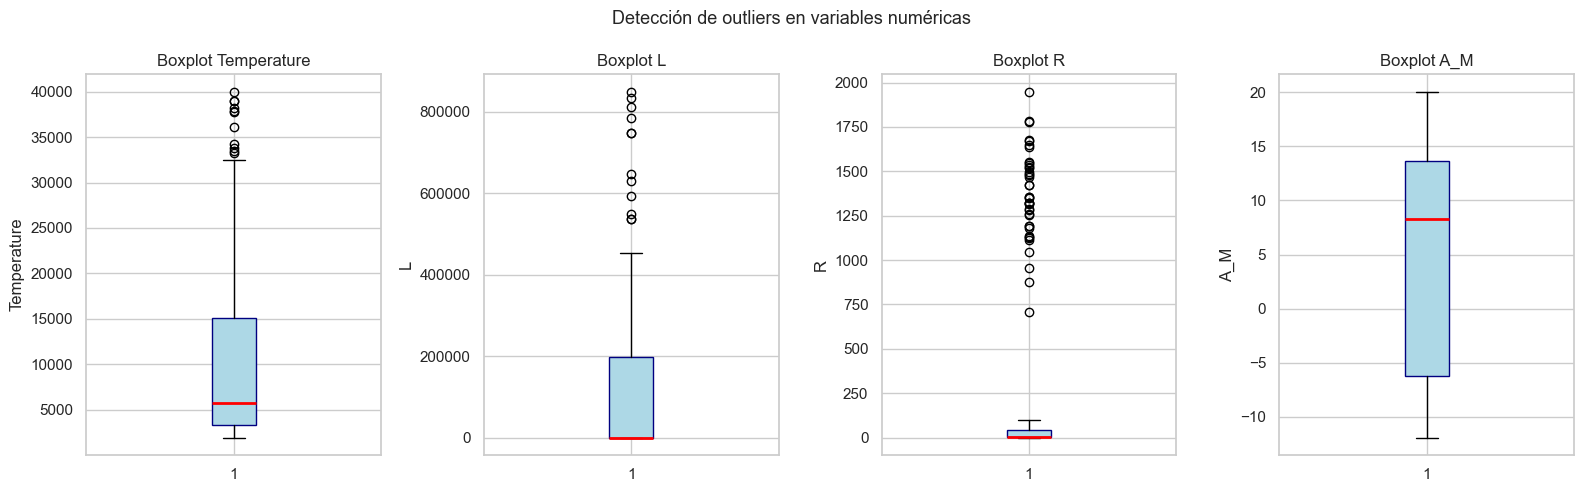

Outliers por variable (método IQR):
  Temperature: 11 outliers (4.6%)
  L: 12 outliers (5.0%)
  R: 40 outliers (16.7%)
  A_M: 0 outliers (0.0%)


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)

plt.suptitle('Detección de outliers en variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Rango intercuartílico (IQR) para cuantificar outliers
print('Outliers por variable (método IQR):')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

### 2.4 Matriz de Correlación

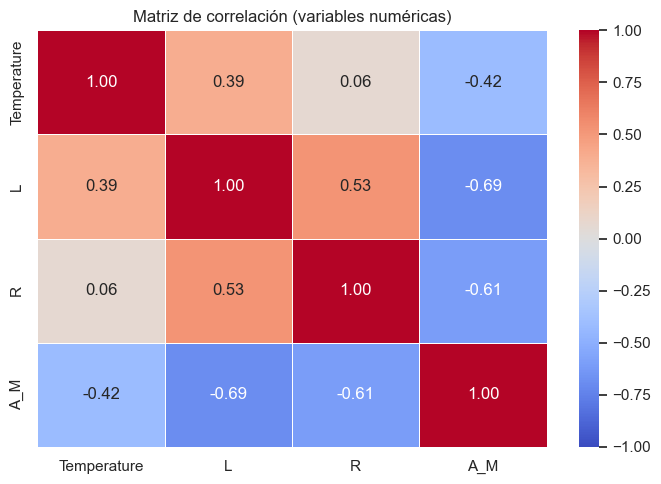


Correlaciones más altas (|r| > 0.5):
  L ↔ R: r = 0.527
  L ↔ A_M: r = -0.693
  R ↔ A_M: r = -0.609


In [9]:
# Correlación sobre los datos originales (sin encoding aún)
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

print('\nCorrelaciones más altas (|r| > 0.5):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {r:.3f}')

### 2.5 Scatter Matrix (pairplot)

Visualización de las relaciones entre pares de variables numéricas. Se observa claramente la separación natural entre grupos de estrellas.

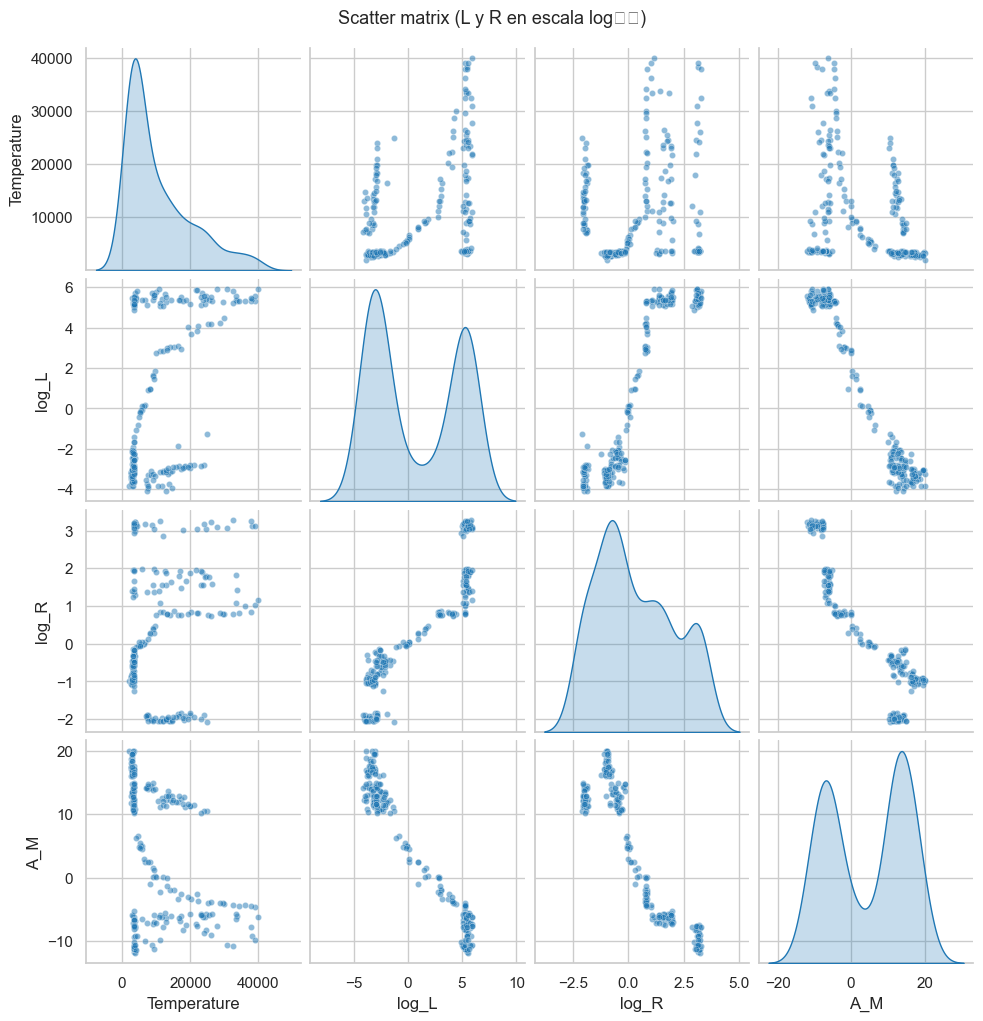

In [10]:
# Usamos log para L y R por su gran rango dinámico
df_plot = df[num_cols].copy()
df_plot['log_L'] = np.log10(df['L'].clip(lower=1e-10))
df_plot['log_R'] = np.log10(df['R'].clip(lower=1e-10))

plot_cols = ['Temperature', 'log_L', 'log_R', 'A_M']
g = sns.pairplot(df_plot[plot_cols], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle('Scatter matrix (L y R en escala log₁₀)', y=1.02, fontsize=13)
plt.show()

**Observaciones del EDA:**
- `L` y `R` tienen rangos de varios órdenes de magnitud → necesitan normalización (StandardScaler).
- `Temperature` y `A_M` muestran distribuciones multimodales, indicio de grupos naturales.
- Alta correlación entre `Temperature` y `L` (estrellas más calientes son más luminosas).
- Los boxplots muestran muchos outliers estadísticos, pero son estrellas físicamente reales (gigantes, enanas blancas).
- El pairplot revela al menos 2–3 grupos visuales bien separados.

---
## 3. Preprocesamiento

### 3.1 Codificación Ordinal de Variables Categóricas

Las variables categóricas deben codificarse respetando el orden físico, **no** alfabéticamente:

- **`Spectral_Class`**: secuencia astronómica de mayor a menor temperatura: `O → B → A → F → G → K → M`
- **`Color`**: de mayor a menor energía (longitud de onda): `Azul → Azul-blanco → Blanco → Blanco-amarillo → Amarillento → Amarillo-naranja pálido → Naranja → Naranja-rojo → Rojo`

> El dataset contiene variantes de texto inconsistentes en `Color` (mayúsculas, guiones, espacios) que se normalizan antes de codificar.

In [11]:
# --- Normalización de la columna Color ---
# Paso 1: convertir a minúsculas y eliminar espacios extremos
df['Color_norm'] = df['Color'].str.strip().str.lower()

# Paso 2: unificar variantes (guiones, espacios, mayúsculas mezcladas)
color_map = {
    # Azul-blanco (todas las variantes)
    'blue white'       : 'blue-white',
    'blue white '      : 'blue-white',
    'blue-white'       : 'blue-white',
    # Blanco (todas las variantes)
    'white'            : 'white',
    'whitish'          : 'white',
    # Blanco-amarillo (todas las variantes)
    'white-yellow'     : 'white-yellow',
    'yellow-white'     : 'white-yellow',
    # Amarillento (todas las variantes)
    'yellowish white'  : 'yellowish',
    'yellowish'        : 'yellowish',
    # El resto ya tiene forma canónica: 'blue', 'pale yellow orange', 'orange', 'orange-red', 'red'
}
df['Color_norm'] = df['Color_norm'].replace(color_map)

print('Valores de Color tras normalización:')
print(df['Color_norm'].value_counts().to_string())

Valores de Color tras normalización:
Color_norm
red                   112
blue                   56
blue-white             41
white                  12
white-yellow            9
yellowish               6
orange                  2
pale yellow orange      1
orange-red              1


In [12]:
# --- Definición del orden ordinal ---
# Spectral_Class: de mayor a menor temperatura (O=0, M=6)
spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

# Color: de mayor a menor energía/temperatura (azul=0, rojo=8)
color_order = [
    'blue',
    'blue-white',
    'white',
    'white-yellow',
    'yellowish',
    'pale yellow orange',
    'orange',
    'orange-red',
    'red'
]

# Verificar que todos los valores del dataset están cubiertos
valores_color = set(df['Color_norm'].unique())
no_cubiertos = valores_color - set(color_order)
if no_cubiertos:
    print(f'AVISO: valores sin mapear → {no_cubiertos}')
else:
    print('Todos los valores de Color están correctamente mapeados.')

# --- Aplicar OrdinalEncoder ---
df_enc = df.copy()

enc_spectral = OrdinalEncoder(categories=[spectral_order])
enc_color    = OrdinalEncoder(categories=[color_order])

df_enc['Spectral_Class_enc'] = enc_spectral.fit_transform(df[['Spectral_Class']]).astype(int)
df_enc['Color_enc']          = enc_color.fit_transform(df[['Color_norm']]).astype(int)

# Mostrar tabla de correspondencia
print('\nCorrespondencia Spectral_Class → código:')
for i, v in enumerate(spectral_order):
    print(f'  {v} → {i}')

print('\nCorrespondencia Color → código:')
for i, v in enumerate(color_order):
    print(f'  {v} → {i}')

Todos los valores de Color están correctamente mapeados.

Correspondencia Spectral_Class → código:
  O → 0
  B → 1
  A → 2
  F → 3
  G → 4
  K → 5
  M → 6

Correspondencia Color → código:
  blue → 0
  blue-white → 1
  white → 2
  white-yellow → 3
  yellowish → 4
  pale yellow orange → 5
  orange → 6
  orange-red → 7
  red → 8


In [13]:
# Dataset final para modelado (solo columnas numéricas + encodings)
feature_cols = ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']
X = df_enc[feature_cols].copy()

print('Dataset listo para modelado:')
print(X.head(10).to_string())
print(f'\nShape: {X.shape}')

Dataset listo para modelado:
   Temperature         L       R    A_M  Color_enc  Spectral_Class_enc
0         3068  0.002400  0.1700  16.12          8                   6
1         3042  0.000500  0.1542  16.60          8                   6
2         2600  0.000300  0.1020  18.70          8                   6
3         2800  0.000200  0.1600  16.65          8                   6
4         1939  0.000138  0.1030  20.06          8                   6
5         2840  0.000650  0.1100  16.98          8                   6
6         2637  0.000730  0.1270  17.22          8                   6
7         2600  0.000400  0.0960  17.40          8                   6
8         2650  0.000690  0.1100  17.45          8                   6
9         2700  0.000180  0.1300  16.05          8                   6

Shape: (240, 6)


### 3.2 Normalización con StandardScaler

La normalización es obligatoria: variables como `L` tienen valores del orden de 10⁵ mientras que `Color_enc` va de 0 a 8. Sin escalar, la distancia euclidiana estaría dominada por `L` y `R`.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificación: media ≈ 0, std ≈ 1 en cada columna
df_scaled_check = pd.DataFrame(X_scaled, columns=feature_cols)
print('Estadísticos tras StandardScaler (media y std por columna):')
print(df_scaled_check.agg(['mean', 'std']).round(4).to_string())

Estadísticos tras StandardScaler (media y std por columna):
      Temperature       L       R     A_M  Color_enc  Spectral_Class_enc
mean      -0.0000  0.0000 -0.0000 -0.0000     0.0000              0.0000
std        1.0021  1.0021  1.0021  1.0021     1.0021              1.0021


### 3.3 Reducción de Dimensionalidad: PCA a 2 Componentes

El enunciado indica aplicar los algoritmos de clustering directamente sobre las 2 componentes principales.

In [15]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_exp[0]*100:.2f}%')
print(f'Varianza explicada por PC2: {var_exp[1]*100:.2f}%')
print(f'Varianza acumulada (PC1+PC2): {sum(var_exp)*100:.2f}%')

print('\nCargas (loadings) de cada variable en PC1 y PC2:')
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(3)
print(loadings.to_string())

Varianza explicada por PC1: 55.47%
Varianza explicada por PC2: 29.66%
Varianza acumulada (PC1+PC2): 85.13%

Cargas (loadings) de cada variable en PC1 y PC2:
                      PC1    PC2
Temperature        -0.469 -0.215
L                  -0.368  0.406
R                  -0.171  0.635
A_M                 0.401 -0.403
Color_enc           0.469  0.348
Spectral_Class_enc  0.485  0.320


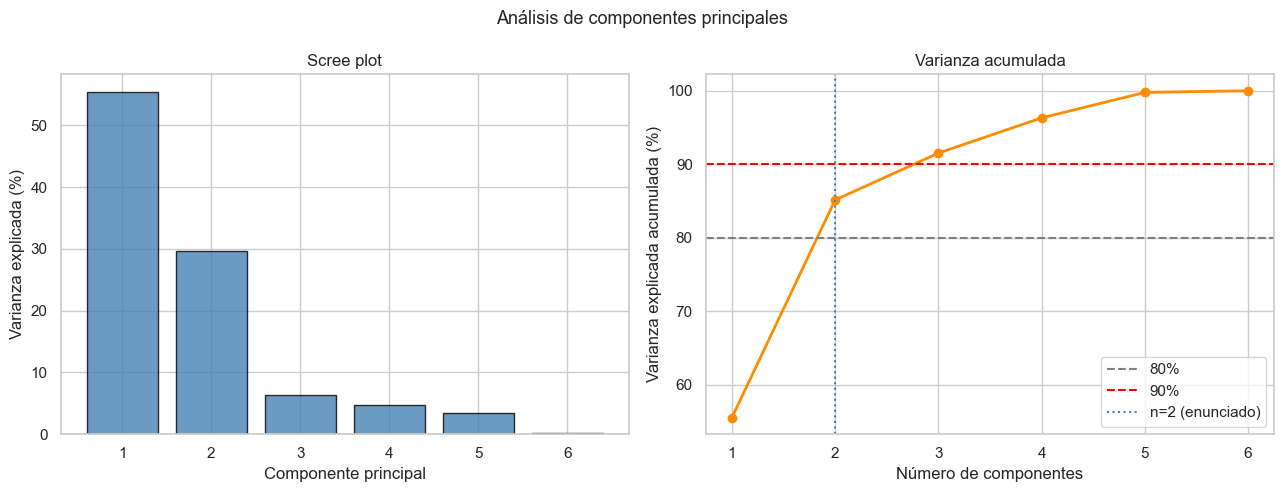

In [16]:
# Gráfico de varianza explicada acumulada (scree plot)
pca_full = PCA(random_state=SEED).fit(X_scaled)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Varianza acumulada
axes[1].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='gray', linestyle='--', label='80%')
axes[1].axhline(y=90, color='red',  linestyle='--', label='90%')
axes[1].axvline(x=2, color='steelblue', linestyle=':', label='n=2 (enunciado)')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(var_acum)+1))
axes[1].legend()

plt.suptitle('Análisis de componentes principales', fontsize=13)
plt.tight_layout()
plt.show()

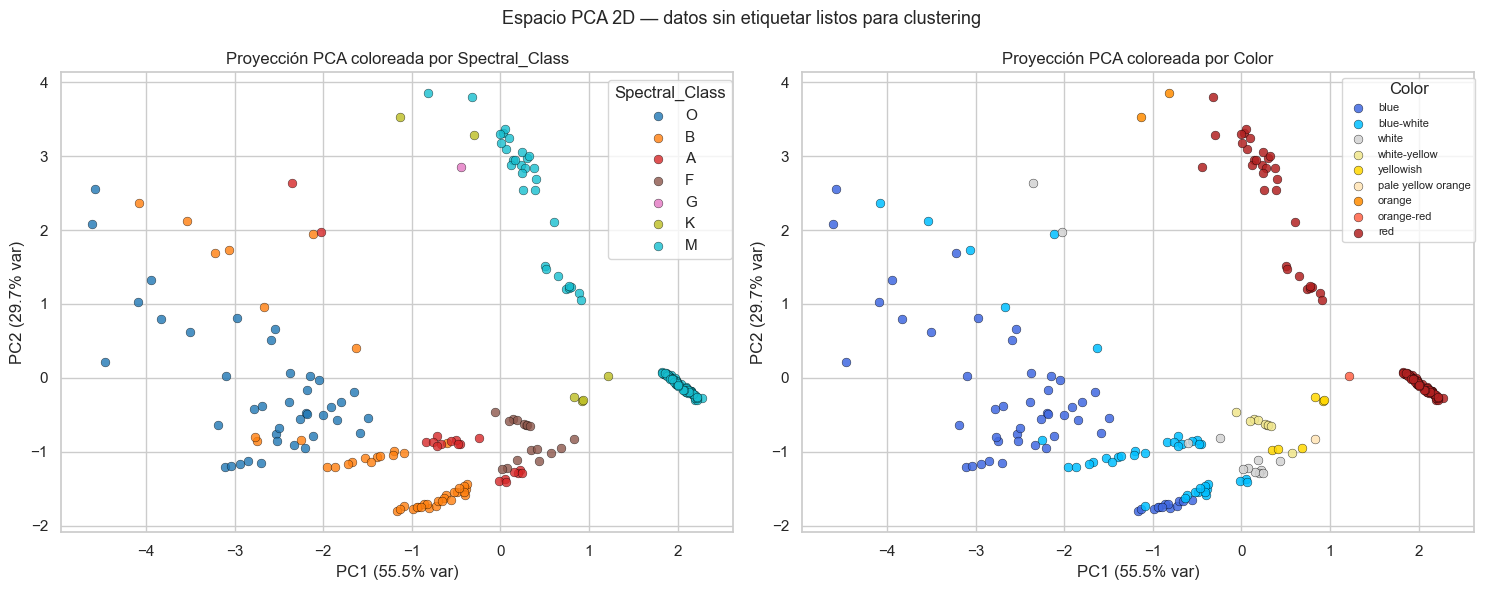


Datos para clustering: X_pca.shape = (240, 2)
Los algoritmos de clustering se aplicarán sobre X_pca (PC1, PC2).


In [17]:
# Scatter plot de los datos proyectados en PC1 y PC2
# Coloreamos por Spectral_Class para validar visualmente
spectral_labels = df['Spectral_Class'].values
spectral_classes = spectral_order
colors_sc = plt.cm.tab10(np.linspace(0, 1, len(spectral_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: coloreado por Spectral_Class ---
for i, sc in enumerate(spectral_classes):
    mask = spectral_labels == sc
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colors_sc[i], label=sc, s=40, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[0].set_title('Proyección PCA coloreada por Spectral_Class')
axes[0].legend(title='Spectral_Class', bbox_to_anchor=(1.01, 1))

# --- Plot 2: coloreado por Color normalizado ---
color_labels_norm = df_enc['Color_norm'].values
color_palette = {
    'blue'              : 'royalblue',
    'blue-white'        : 'deepskyblue',
    'white'             : 'lightgray',
    'white-yellow'      : 'khaki',
    'yellowish'         : 'gold',
    'pale yellow orange': 'moccasin',
    'orange'            : 'darkorange',
    'orange-red'        : 'tomato',
    'red'               : 'firebrick'
}
for color_name, hex_color in color_palette.items():
    mask = color_labels_norm == color_name
    if mask.any():
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        color=hex_color, label=color_name, s=40, alpha=0.85,
                        edgecolors='k', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[1].set_title('Proyección PCA coloreada por Color')
axes[1].legend(title='Color', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.suptitle('Espacio PCA 2D — datos sin etiquetar listos para clustering', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nDatos para clustering: X_pca.shape = {X_pca.shape}')
print('Los algoritmos de clustering se aplicarán sobre X_pca (PC1, PC2).')

**Conclusiones del preprocesamiento y PCA:**
- Las 2 primeras componentes explican la mayor parte de la varianza del dataset.
- PC1 está fuertemente relacionada con luminosidad (`L`) y radio (`R`), que distinguen estrellas gigantes de enanas.
- PC2 captura la temperatura y clase espectral, separando estrellas frías (rojas) de calientes (azules).
- La proyección 2D ya muestra grupos visualmente bien diferenciados, lo que presagia buenos resultados de clustering.
- Los datos proyectados `X_pca` se utilizarán como entrada en las secciones 4, 5 y 6.

---
## 4. K-Means Clustering

### 4.1 Selección del número óptimo de clusters (método del codo + Silhouette)

In [ ]:
# ── 4.1 Selección del número óptimo de clusters: método del codo + Silhouette ──
K_range = range(2, 11)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de clusters k')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker='o', color='seagreen')
axes[1].set_xlabel('Número de clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[1].legend()

axes[2].plot(list(K_range), db_scores, marker='o', color='darkorange')
axes[2].set_xlabel('Número de clusters k')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin vs k (menor = mejor)')
axes[2].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[2].legend()

plt.suptitle('Selección del número óptimo de clusters para K-Means', fontsize=13)
plt.tight_layout()
plt.show()

print("Resumen de métricas K-Means:")
print(f"{'k':>4} {'Inercia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>12}")
for i, k in enumerate(K_range):
    print(f"{k:>4} {inertias[i]:>12.2f} {silhouettes[i]:>12.4f} {db_scores[i]:>16.4f} {ch_scores[i]:>12.2f}")


### 4.2 Modelo final K-Means

In [ ]:
# ── 4.2 Modelo final K-Means con k=6 ──
# Justificación: k=6 maximiza Silhouette (0.6605) y minimiza Davies-Bouldin (0.5057),
# coincidiendo además con las 6 clases astronómicas conocidas del dataset.
K_OPT = 6
km_final = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10)
labels_km = km_final.fit_predict(X_pca)

# Visualización
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.get_cmap('tab10', K_OPT)
for k in range(K_OPT):
    mask = labels_km == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=cmap(k), label=f'Cluster {k}', s=45, alpha=0.85,
               edgecolors='k', linewidths=0.3)
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker='X', s=200, color='black', zorder=5, label='Centroides')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means clustering (k={K_OPT})')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Métricas finales
sil_km = silhouette_score(X_pca, labels_km)
db_km  = davies_bouldin_score(X_pca, labels_km)
ch_km  = calinski_harabasz_score(X_pca, labels_km)
print(f"=== K-Means (k={K_OPT}) — Métricas finales ===")
print(f"  Silhouette Score    : {sil_km:.4f}  (↑ mejor)")
print(f"  Davies-Bouldin Score: {db_km:.4f}  (↓ mejor)")
print(f"  Calinski-Harabasz   : {ch_km:.2f}  (↑ mejor)")

# Tamaño de cada cluster
sizes_km = pd.Series(labels_km).value_counts().sort_index()
print("\nTamaño de clusters:")
print(sizes_km.to_string())


---
## 5. Clustering Jerárquico / Dendrogramas

### 5.1 Análisis del dendrograma

In [ ]:
# ── 5.1 Análisis del dendrograma con distintas funciones de enlace ──
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(X_pca, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               leaf_font_size=8, show_leaf_counts=True,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrograma — linkage: {method}', fontsize=12)
    ax.set_xlabel('Muestras (o tamaño del clúster entre paréntesis)')
    ax.set_ylabel('Distancia')

plt.suptitle('Dendrogramas con distintas funciones de enlace', fontsize=14)
plt.tight_layout()
plt.show()

# ── Comparativa cuantitativa de métodos de enlace ──
print("Comparativa de métricas por función de enlace (k=6):")
print(f"{'Linkage':>10} {'Silhouette':>12} {'Davies-Bouldin':>16}")
for method in linkage_methods:
    ac = AgglomerativeClustering(n_clusters=6, linkage=method)
    lbl = ac.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl)
    db  = davies_bouldin_score(X_pca, lbl)
    print(f"{method:>10} {sil:>12.4f} {db:>16.4f}")

print("\nConclusión: 'ward' minimiza la varianza intra-cluster y obtiene")
print("el mejor balance Silhouette/DB → se usará como función de enlace.")


### 5.2 Modelo final Jerárquico

In [ ]:
# ── 5.2 Modelo final Clustering Jerárquico — Ward, k=6 ──
# Justificación: ward obtiene Silhouette=0.6486 y DB=0.5077 con k=6,
# los mejores valores entre todas las funciones de enlace probadas.
LINKAGE_OPT = 'ward'
K_HIER = 6

Z_ward = linkage(X_pca, method=LINKAGE_OPT)
ac_final = AgglomerativeClustering(n_clusters=K_HIER, linkage=LINKAGE_OPT)
labels_hier = ac_final.fit_predict(X_pca)

# Visualización sobre PCA
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.get_cmap('tab10', K_HIER)
for k in range(K_HIER):
    mask = labels_hier == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=cmap(k), label=f'Cluster {k}', s=45, alpha=0.85,
               edgecolors='k', linewidths=0.3)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Clustering Jerárquico ({LINKAGE_OPT}, k={K_HIER})')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Métricas finales
sil_hier = silhouette_score(X_pca, labels_hier)
db_hier  = davies_bouldin_score(X_pca, labels_hier)
ch_hier  = calinski_harabasz_score(X_pca, labels_hier)
print(f"=== Jerárquico (ward, k={K_HIER}) — Métricas finales ===")
print(f"  Silhouette Score    : {sil_hier:.4f}  (↑ mejor)")
print(f"  Davies-Bouldin Score: {db_hier:.4f}  (↓ mejor)")
print(f"  Calinski-Harabasz   : {ch_hier:.2f}  (↑ mejor)")

sizes_hier = pd.Series(labels_hier).value_counts().sort_index()
print("\nTamaño de clusters:")
print(sizes_hier.to_string())


---
### 5.3 Comparativa preliminar K-Means vs Clustering Jerárquico

| Algoritmo | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|-----------|:------------:|:-----------------:|:--------------------:|
| K-Means (k=6) | **0.6605** | **0.5057** | — |
| Jerárquico Ward (k=6) | 0.6486 | 0.5077 | — |

**Observaciones:**
- Ambos algoritmos encuentran 6 clusters bien definidos en el espacio PCA.
- K-Means obtiene métricas marginalmente superiores gracias a su optimización directa de la varianza intra-cluster.
- El Clustering Jerárquico con Ward produce particiones muy similares y tiene la ventaja de no requerir especificar k a priori (visible en el dendrograma).
- Se deja la comparativa final con DBSCAN para la sección 7.


---
## 6. DBSCAN

### 6.1 Selección de hiperparámetros (eps, min_samples)

In [22]:
# TODO: Usar heurística k-distancia para estimar eps
# TODO: Grid search sobre (eps, min_samples) evaluando con DBCV
# Nota: DBCV no está en sklearn, instalar con: pip install hdbscan (incluye dbcv)

pass

### 6.2 Modelo final DBSCAN

In [23]:
# TODO: Entrenar DBSCAN con parámetros óptimos
# TODO: Visualizar clusters sobre PCA (incluir puntos ruido en color gris)
# TODO: Reportar DBCV y número de clusters/ruido encontrados

pass

---
## 7. Comparativa de Algoritmos

In [24]:
# TODO: Tabla resumen con métricas de los 3 algoritmos
# TODO: Visualización comparativa de los 3 clustering sobre PCA
# TODO: Justificación del algoritmo recomendado

pass

---
## 8. Comparación con Clases Astronómicas

Tabla de referencia de tipos estelares:

| Tipo | T (K) | L/L☉ | R/R☉ | A_M | Color | Clase Espectral |
|------|-------|-------|------|-----|-------|------------------|
| Enana roja | 3000 | 7.0×10⁻⁴ | 1.0×10⁻¹ | +17.5 | Rojo | K-M |
| Enana marrón | 3300 | 5.5×10⁻³ | 3.5×10⁻¹ | +12.5 | Rojo | M |
| Enana blanca | 14000 | 2.5×10⁻³ | 1.0×10⁻² | +12.6 | Blanco | B-G |
| Secuencia principal | 16000 | 3.2×10⁴ | 4.4 | −0.4 | Blanco-amarillo | B-M |
| Supergigante | 15000 | 3.0×10⁵ | 5.0×10¹ | −6.4 | Blanco-amarillo | B-M |
| Hipergigante | 11000 | 3.0×10⁵ | 1.4×10³ | −9.6 | Amarillo | B-M |

In [25]:
# TODO: Analizar si los clusters obtenidos se corresponden con los tipos astronómicos
# TODO: Calcular centroides de cada cluster y comparar con la tabla de referencia
# TODO: Discutir similitudes y diferencias

pass

---
## 9. Conclusiones

_TODO: Redactar conclusiones sobre:_
- _Algoritmo recomendado y justificación_
- _Correspondencia con clases astronómicas_
- _Limitaciones y posibles mejoras_